# Calculate and Visualize Annual Temperature Anomalies

This tutorial shows you how to:

1. load monthly mean temperature data from a CSV file,
2. aggregate the monthly values to annual means using pandas,
3. calculate annual anomalies relative to a user-defined reference period,
4. save the calculated results as CSV
5. visualize the anomalies, and
6. save the resulting figure.

The workflow is split into small functions so that each step has one clear responsibility and can be reused or tested independently.

### Notes

The tutorial assumes that the monthly input time series has already been checked for missing observations. Missing months can affect annual means and should therefore be checked before interpreting the anomalies.

# 1. Load Libraries

In [99]:
# Work with DataFrames
import pandas as pd

# Visualize data
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np

# Filepaths and saving data
from pathlib import Path

## 2. Expected input data

The CSV must contain:

- a date column in `YYYY-MM-DD` format,
- one numeric column containing the monthly mean temperature values,
- a column containing one consistent unit.

The relevant input columns are identified explicitly by name. This makes the workflow independent of column order and allows datasets with different column names to use the same functions. For example, if your date column is named `timestamp`, you can specify `date_column="timestamp"`. However, in the example below we can see that `date_column="date"`


<br>

Example:

| date | air_temperature_mean_celsius | unit |
|---|---:|---|
| 1881-01-01 | -2.69 | °C |
| 1881-02-01 | 3.19 | °C |

<br>

This tutorial calculates **annual mean temperature anomalies**. It therefore uses the arithmetic mean when aggregating monthly values to annual values.

## 3. Defining the calculation functions

The calculation is:

**annual anomaly = annual mean − reference-period mean**

The individual functions below keep loading, aggregation, reference-period selection, and anomaly calculation separate.

In [100]:
# Load a CSV file and parse its date column as datetime
def make_datetimes(df, date_column="date"):
    df[date_column] = pd.to_datetime(df[date_column], format="%Y-%m-%d")
    return df

In [101]:
# Calculate one annual mean value for each calendar year
def calculate_annual_mean(df, value_column, date_column="date"):
    return (
        df.groupby(df[date_column].dt.year)[value_column]
        .mean()
        .rename("annual_mean")
    )

In [102]:
# Select the years for the reference period
def select_reference_period(annual_mean, reference_start_year, reference_end_year):
    return annual_mean[
        (annual_mean.index >= reference_start_year)
        & (annual_mean.index <= reference_end_year)]

In [103]:
# Calculate the mean value of the selected reference period
def calculate_reference_mean(reference_period):
    return reference_period.mean()

In [104]:
# Calculate anomaly relative to reference mean
def calculate_anomaly(annual_mean, reference_mean):
    return (annual_mean - reference_mean).rename("anomaly")

## 4. Combine the calculation steps into one reusable workflow

Instead of calling each single function from before, we wrap the individual functions into `load_anomaly_results()`

The function also validates important assumptions before calculating the result:

- the required columns must exist,
- the input must contain exactly one unit,
- the selected reference period must contain data.

Also: The returned DataFrame uses `year` rather than `date`, because the monthly dates have already been aggregated to annual values.

In [105]:
def load_anomaly_results(
    filepath,
    reference_start_year,
    reference_end_year,
    value_column,
    date_column="date",
    unit_column="unit"
):

    # Validate reference period
    if reference_start_year > reference_end_year:
        raise ValueError(
            "reference_start_year must be smaller than or equal to "
            "reference_end_year."
        )

    # Load data
    df = pd.read_csv(filepath)

    # Validate required columns
    required_columns = {
        date_column,
        value_column,
        unit_column
    }

    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {sorted(missing_columns)}"
        )

    # Convert dates only AFTER confirming the column exists
    df = make_datetimes(
        df=df,
        date_column=date_column
    )

    # Validate unit
    units = df[unit_column].dropna().unique()

    if len(units) != 1:
        raise ValueError(
            "Expected exactly one unit in the input data."
        )

    unit = units[0]

    # Calculate annual mean
    annual_mean = calculate_annual_mean(
        df=df,
        value_column=value_column,
        date_column=date_column
    )

    # Select reference period
    reference_period = select_reference_period(
        annual_mean=annual_mean,
        reference_start_year=reference_start_year,
        reference_end_year=reference_end_year
    )

    if reference_period.empty:
        raise ValueError(
            "No data available for the selected reference period."
        )

    # Calculate reference mean
    reference_mean = calculate_reference_mean(
        reference_period=reference_period
    )

    # Calculate anomalies
    anomaly = calculate_anomaly(
        annual_mean=annual_mean,
        reference_mean=reference_mean
    )

    # Final result
    result = pd.DataFrame({
        "year": annual_mean.index,
        "value": annual_mean.values,
        "reference": reference_mean,
        "anomaly": anomaly.values,
        "unit": unit,
        "reference_start_year": reference_start_year,
        "reference_end_year": reference_end_year
    })

    return result

In [106]:
# Let's also make sure to save our results in a CSV

def save_calculated_results(df, save_as_filename, output_directory="data/processed"):
  output_directory = Path(output_directory)

  output_directory.mkdir(
      parents=True,
      exist_ok=True
  )

  filepath = output_directory / save_as_filename

  df.to_csv(filepath, index=False)

  print(f"Your calculated results have been saved to: {filepath}")

  return filepath

## 5. Define the visualization function

By default, the plot uses the complete period available in the calculated DataFrame. A shorter plotting period can be selected with `plot_start_year` and `plot_end_year`.

The colour scale is normalized using the complete anomaly series rather than only the displayed subset. This keeps the meaning of the colours consistent when different plotting periods are compared.

`visualize_anomalies()` returns both the Matplotlib `Figure` and `Axes` objects. Returning them explicitly allows the caller to display, modify, or save the exact figure created by the function.

In [107]:
# Functions that visualize the anomalies

def visualize_anomalies(df, climate_variable, plot_start_year=None, plot_end_year=None,
              year_tick_interval=10, stylesheet="ggplot", title="Annual Anomalies"):

    # We use the full timeframe by default
    if plot_start_year is None:
        plot_start_year = df["year"].min()

    if plot_end_year is None:
        plot_end_year = df["year"].max()

    # Validate plotting period
    if plot_start_year > plot_end_year:
        raise ValueError(
            "plot_start_year must be smaller than or equal to plot_end_year."
        )

    # Select plotting period
    plot_df = df[
        (df["year"] >= plot_start_year) &
        (df["year"] <= plot_end_year)
    ].copy()

    if plot_df.empty:
        raise ValueError(
            "No data available for the selected plotting period."
        )

    # Validate unit
    units = df["unit"].dropna().unique()

    if len(units) != 1:
        raise ValueError(
            "Expected exactly one unit in the dataframe."
        )

    unit = units[0]

    # Use full dataset for consistent colour normalization
    color_limit = df["anomaly"].abs().max()

    norm = mcolors.TwoSlopeNorm(
        vmin=-color_limit,
        vcenter=0,
        vmax=color_limit
    )

    colors = cm.RdBu_r(
        norm(plot_df["anomaly"])
    )

    # Apply stylesheet locally
    with plt.style.context(stylesheet):

        fig, ax = plt.subplots(
            figsize=(13, 6)
        )

        ax.bar(
            plot_df["year"],
            plot_df["anomaly"],
            color=colors,
            width=0.85,
            edgecolor="none",
            zorder=3
        )

        # Reference line
        ax.axhline(
            y=0,
            color="black",
            linewidth=0.6,
            zorder=2
        )

        # Labels
        ax.set_title(
            title,
            loc="left",
            fontsize=18,
            pad=18
        )

        ax.set_ylabel(
            f"{climate_variable} anomaly ({unit})",
            fontsize=12
        )

        ax.set_xlabel("")

        # Horizontal grid lines
        ax.grid(
            axis="y",
            linewidth=2,
            alpha=0.25,
            zorder=0
        )

        ax.grid(
            axis="x",
            visible=False
        )


        # Typography
        ax.tick_params(
            axis="both",
            colors="#333333",
            labelsize=11,
            length=0
        )

        ax.margins(x=0.01)

        tick_years = np.arange(
        plot_start_year,
        plot_end_year + 1,
        year_tick_interval
        )

        ax.set_xticks(tick_years)

        fig.tight_layout()

    return fig, ax

## 6. Define the figure-saving function

Saving is kept separate from visualization. The function receives the exact `Figure` object to save, creates the output directory if necessary, and returns the resulting file path.

In [108]:
def save_figure(fig, save_as_filename, output_directory="figures", dpi=300):

    output_directory = Path(output_directory)

    output_directory.mkdir(
        parents=True,
        exist_ok=True
    )

    filepath = output_directory / save_as_filename

    fig.savefig(
        filepath,
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white"
    )

    print(f"Your figure has been saved to: {filepath}")

    return filepath

## 7. Run the workflow on the Kerpen example

The example below uses monthly mean air temperature data for Kolpingstadt Kerpen.

The file path is relative to the repository. Place the CSV in the `data/` directory before running the example.

In [109]:
# First, assign the filepath to the variable fp (or load in your own data)

fp = (Path("data")/"air_temperature_mean_celsius_Kerpen_1881_2026.csv")

# or if you are working with GoogleCollab
# fp = "/content/air_temperature_mean_celsius_Kerpen_1881_2026.csv"

In [114]:
# We call load_anomaly_results() on the CSV from fp
# Notice that the load_anomaly_results() function bundles all functions from cell 2

years = load_anomaly_results(
    filepath=fp,
    value_column="air_temperature_mean_celsius", # or whatever your column is called
    reference_start_year=1971, # you can define other reference periods for your anomaly calculations
    reference_end_year=2000, # you should use a 30 year period at least
    #date_column="date", # this is the default name
    #unit_column="unit" #this is also the default name already
)

years.head()

,year,value,reference,anomaly,unit,reference_start_year,reference_end_year
0,1881,9.437838,10.157895,-0.720058,°C,1971,2000
1,1882,10.120495,10.157895,-0.037400,°C,1971,2000
2,1883,9.756907,10.157895,-0.400988,°C,1971,2000
3,1884,10.650976,10.157895,0.493081,°C,1971,2000
4,1885,9.516667,10.157895,-0.641229,°C,1971,2000


In [115]:
# Save the df from above to a CSV
saved_data = save_calculated_results(
    df=years,
    save_as_filename="temperature_anomalies_kerpen.csv"
)


Your calculated results have been saved to: data/processed/temperature_anomalies_kerpen.csv


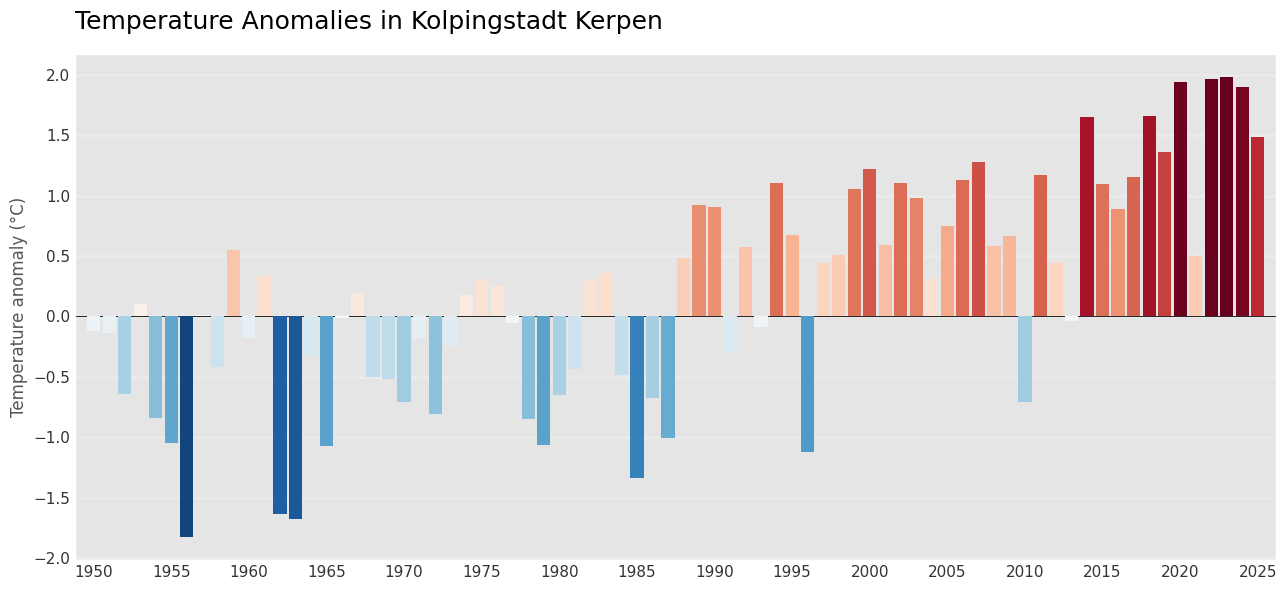

In [116]:
# Next we call visualize_anomalies() to create the anomaly plot
"""plot_start_year` and `plot_end_year` control only what is displayed. They do **not** change the reference period used to calculate the anomalies. If both are omitted, the complete available time series is plotted."""

fig, ax = visualize_anomalies(
    df=years,
    climate_variable="Temperature",
    plot_start_year=1950, #You can change the timeframe that appears in the plot
    plot_end_year=2025, #by adjusting plot_start_year and plot_end_year
    year_tick_interval=5,
    title="Temperature Anomalies in Kolpingstadt Kerpen"
)

# fig

## 8. Save the figure

The visualization function returns `fig`, and that exact object is passed to `save_figure()`.

The returned `saved_file` variable contains the path where the file was written.

In [117]:
# Lastly, call saved_file() to save the plots you made to a format and filename of your choice

saved_file = save_figure(
    fig=fig,
    save_as_filename="temperature_anomalies_kerpen_1950_2025.png"
)

plt.close(fig)

Your figure has been saved to: figures/temperature_anomalies_kerpen_1950_2025.png


## 9. Using the tutorial as a blueprint

The example focuses on converting **monthly mean temperature to annual mean temperature anomalies**.

This notebook examplifies how to write small functions and automate calculations and visualizations for similar and repeating actions.

For another temperature dataset, the main values you normally need to change are:

- `fp`: input CSV path,
- `value_column`: name of the numeric temperature column,
- `reference_start_year` and `reference_end_year`,
- optional plotting period and tick interval,
- plot title and climate-variable label.

Other climate variables may require a different annual aggregation. For example, a variable that should be accumulated over a year should not automatically use `calculate_annual_mean()`. Keeping that assumption explicit is preferable to hiding it inside a generic function. You could therefore go and tweak the aggregation method in `calculate_annual_mean()` if you need to sum your variable, and so on.